<a href="https://colab.research.google.com/github/1rfanb/this_is_collab/blob/main/climate_day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import plotly.express as px

In [3]:
data=pd.read_csv("/content/DailyDelhiClimateTrain.csv")

In [4]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
data.tail()

,date,meantemp,humidity,wind_speed,meanpressure
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000
1461,2017-01-01,10.000000,100.000000,0.000000,1016.000000


In [6]:
data.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [9]:
data.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [11]:
figure=px.line(data,
               x="date",
               y="meantemp",
               title="Mean Temp in Delhi overs Years")
figure.show()

In [13]:
figure=px.line(data,
               x="date",
               y="humidity",
               title="Humidity Temp in Delhi overs Years")
figure.show()

In [14]:
figure=px.line(data,
               x="date",
               y="wind_speed",
               title="Wind speed Temp in Delhi overs Years")
figure.show()

In [18]:
figure=px.scatter(data_frame=data,
                  x="humidity",
                  y="meantemp",
                  size="meantemp",
                  trendline="ols",
                  title="Humidity vs Mean Temp")
figure.show()

In [22]:
data["date"]=pd.to_datetime(data["date"],format="%Y-%m-%d")
data["year"]=data["date"].dt.year
data["month"]=data["date"].dt.month
print(data.head)

<bound method NDFrame.head of            date   meantemp    humidity  wind_speed  meanpressure  year  month
0    2013-01-01  10.000000   84.500000    0.000000   1015.666667  2013      1
1    2013-01-02   7.400000   92.000000    2.980000   1017.800000  2013      1
2    2013-01-03   7.166667   87.000000    4.633333   1018.666667  2013      1
3    2013-01-04   8.666667   71.333333    1.233333   1017.166667  2013      1
4    2013-01-05   6.000000   86.833333    3.700000   1016.500000  2013      1
...         ...        ...         ...         ...           ...   ...    ...
1457 2016-12-28  17.217391   68.043478    3.547826   1015.565217  2016     12
1458 2016-12-29  15.238095   87.857143    6.000000   1016.904762  2016     12
1459 2016-12-30  14.095238   89.666667    6.266667   1017.904762  2016     12
1460 2016-12-31  15.052632   87.000000    7.325000   1016.100000  2016     12
1461 2017-01-01  10.000000  100.000000    0.000000   1016.000000  2017      1

[1462 rows x 7 columns]>


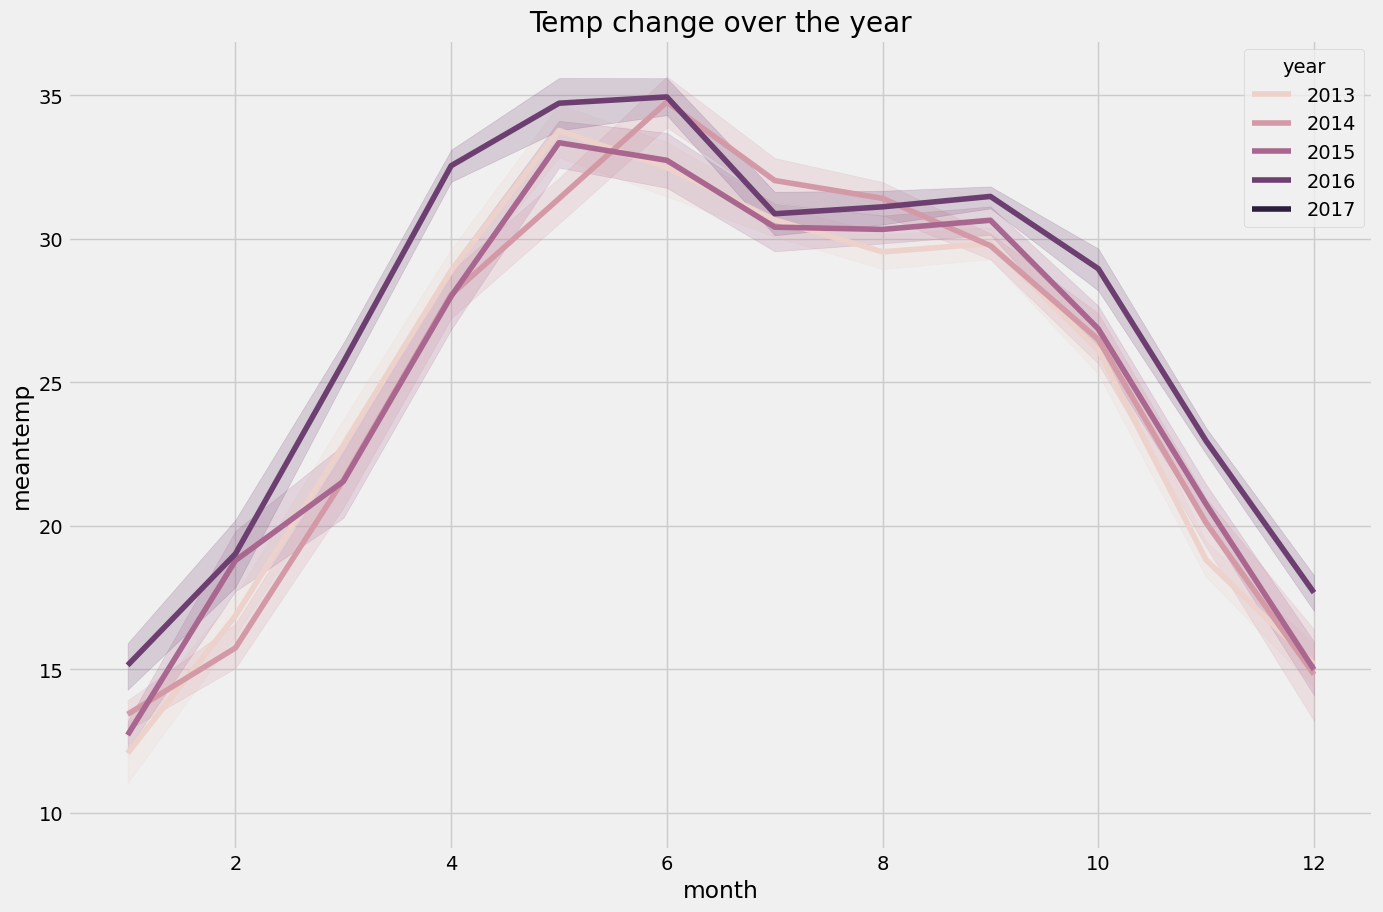

In [23]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15,10))
plt.title("Temp change over the year")
sns.lineplot(data=data,
             x="month",
             y="meantemp",
             hue="year")
plt.show()

In [25]:
!pip install prophet

In [29]:
forecast_data=data.rename(columns={"date":"ds","meantemp":"y"})
print(forecast_data)

             ds          y    humidity  wind_speed  meanpressure  year  month
0    2013-01-01  10.000000   84.500000    0.000000   1015.666667  2013      1
1    2013-01-02   7.400000   92.000000    2.980000   1017.800000  2013      1
2    2013-01-03   7.166667   87.000000    4.633333   1018.666667  2013      1
3    2013-01-04   8.666667   71.333333    1.233333   1017.166667  2013      1
4    2013-01-05   6.000000   86.833333    3.700000   1016.500000  2013      1
...         ...        ...         ...         ...           ...   ...    ...
1457 2016-12-28  17.217391   68.043478    3.547826   1015.565217  2016     12
1458 2016-12-29  15.238095   87.857143    6.000000   1016.904762  2016     12
1459 2016-12-30  14.095238   89.666667    6.266667   1017.904762  2016     12
1460 2016-12-31  15.052632   87.000000    7.325000   1016.100000  2016     12
1461 2017-01-01  10.000000  100.000000    0.000000   1016.000000  2017      1

[1462 rows x 7 columns]


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


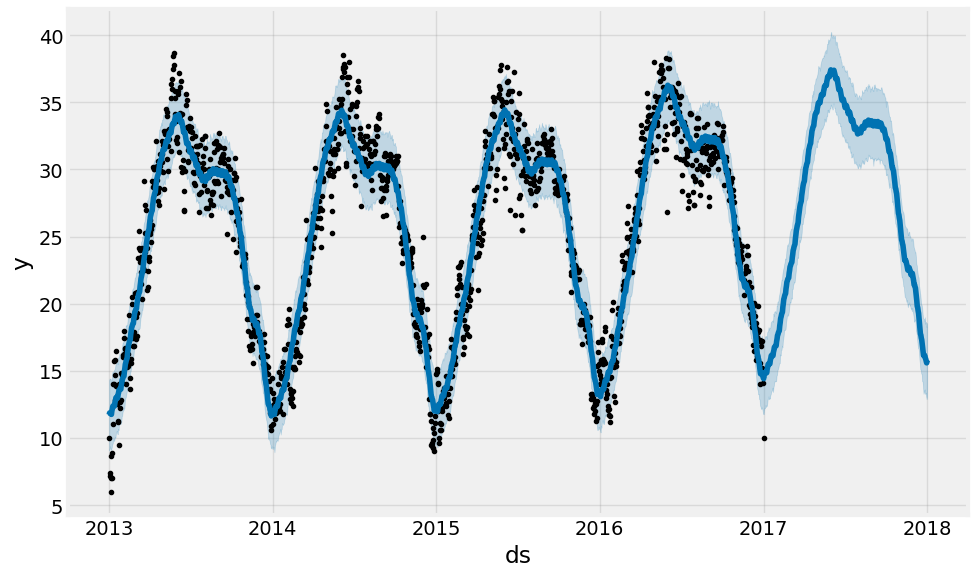

In [34]:
import pandas as pd

from prophet import Prophet

forecast_data = data.rename(columns={

"date": "ds",

"meantemp": "y"

})

forecast_data=forecast_data[["ds", "y"]]

forecast_data["ds"] = pd.to_datetime(forecast_data["ds"])

forecast_data["y"] = pd.to_numeric(forecast_data["y"], errors="coerce")

forecast_data =forecast_data.dropna()

model =Prophet()

model.fit(forecast_data)

forecasts=model.make_future_dataframe(periods=365)

predictions=model.predict(forecasts)
from prophet.plot import plot
fig=plot(model,predictions)
fig.show()